In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make src folder importable when notebook is located in notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from losses import (
    mosfet_rds_on_temperature,
    mosfet_conduction_loss,
    mosfet_switching_loss,
    mosfet_gate_drive_loss,
    diode_loss,
    linear_regulator_loss,
    buck_converter_loss,
    shunt_loss,
)

from thermal_models import (
    steady_temperature,
    first_order_thermal_response,
    simulate_pcb_coupled_network,
    thermal_status,
)

from plotting import (
    plot_temperature_bar,
    plot_transient_temperatures,
    plot_parameter_sweep,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [9]:
import sys
import importlib
import shutil
from pathlib import Path

src_path = Path("/workspace/src")
module_path = src_path / "thermal_models.py"
pycache_path = src_path / "__pycache__"

# Remove old module from current Python session
sys.modules.pop("thermal_models", None)

# Remove cached bytecode
if pycache_path.exists():
    shutil.rmtree(pycache_path)

# Make sure /workspace/src is in import path
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Refresh import system
importlib.invalidate_caches()

import thermal_models

print("Loaded from:", thermal_models.__file__)
print("Available names:")
print([name for name in dir(thermal_models) if not name.startswith("__")])

Loaded from: /workspace/src/thermal_models.py
Available names:
['annotations', 'first_order_thermal_response', 'np', 'simulate_pcb_coupled_network', 'simulate_single_component_ode', 'solve_ivp', 'steady_temperature', 'thermal_status', 'thermal_time_constant']


In [11]:
# System parameters
V_supply = 24.0       # V
I_motor = 10.0        # A
f_pwm = 20e3          # Hz
duty = 0.5            # -
T_ambient = 25.0      # °C

system_parameters = pd.DataFrame({
    "Parameter": [
        "Supply voltage",
        "Motor current",
        "PWM frequency",
        "Duty cycle",
        "Ambient temperature",
    ],
    "Symbol": [
        "V_supply",
        "I_motor",
        "f_pwm",
        "D",
        "T_ambient",
    ],
    "Value": [
        V_supply,
        I_motor,
        f_pwm,
        duty,
        T_ambient,
    ],
    "Unit": [
        "V",
        "A",
        "Hz",
        "-",
        "°C",
    ],
})

system_parameters

,Parameter,Symbol,Value,Unit
0,Supply voltage,V_supply,24.0,V
1,Motor current,I_motor,10.0,A
2,PWM frequency,f_pwm,20000.0,Hz
3,Duty cycle,D,0.5,-
4,Ambient temperature,T_ambient,25.0,°C


In [12]:
# Component data
# Datasheet values where available, rough Cth values for transient estimates.

mosfet_high_side = {
    "name": "Q1 High-Side MOSFET",
    "part_number": "IRLZ44N",

    "Vds_max": 55.0,          # V
    "Rds_on_10V": 0.022,      # Ohm
    "Rds_on_5V": 0.025,       # Ohm
    "Rds_on_used": 0.022,     # Ohm, driven by IR2104
    "Qg": 48e-9,             # C
    "tr": 84e-9,             # s
    "tf": 15e-9,             # s

    "Rth_JC": 1.9,            # °C/W
    "Rth_JA": 62.0,           # °C/W
    "Tj_max": 175.0,          # °C
    "Cth": 5.0,               # J/°C, estimated

    "package": "TO-220AB",
}

mosfet_low_side = {
    "name": "Q2 Low-Side MOSFET",
    "part_number": "IRLZ44N",

    "Vds_max": 55.0,          # V
    "Rds_on_10V": 0.022,      # Ohm
    "Rds_on_5V": 0.025,       # Ohm
    "Rds_on_used": 0.022,     # Ohm, driven by IR2104
    "Qg": 48e-9,             # C
    "tr": 84e-9,             # s
    "tf": 15e-9,             # s

    "Rth_JC": 1.9,            # °C/W
    "Rth_JA": 62.0,           # °C/W
    "Tj_max": 175.0,          # °C
    "Cth": 5.0,               # J/°C, estimated

    "package": "TO-220AB",
}

gate_driver = {
    "name": "U1 Half-Bridge Gate Driver",
    "part_number": "IR2104",

    "Vcc": 12.0,              # V
    "Vcc_min": 10.0,          # V
    "Vcc_max": 20.0,          # V
    "Voffset_max": 600.0,     # V

    "Io_source": 130e-3,      # A
    "Io_sink": 270e-3,        # A
    "deadtime_typ": 520e-9,   # s
    "turn_on_delay_typ": 680e-9,
    "turn_off_delay_typ": 150e-9,

    "Rth_JA_PDIP": 125.0,     # °C/W
    "Rth_JA_SOIC": 200.0,     # °C/W
    "Tj_max": 150.0,          # °C
    "Cth": 1.0,               # J/°C, estimated

    "package": "8-pin PDIP or SOIC",
}

shunt = {
    "name": "R5 Current Sense Shunt",
    "series": "ROHM GMR",

    "R": 0.010,               # Ohm
    "tolerance": 0.01,        # ±1 %
    "TCR": 25e-6,             # 1/°C

    "current_nominal": 10.0,  # A
    "power_rating_used": 7.0, # W

    "Rth_JA": 35.0,           # °C/W, estimated
    "T_max": 170.0,           # °C
    "Cth": 2.0,               # J/°C, estimated

    "resistance_code": "10L0",
    "product_code": "JB",
}

freewheel_diode = {
    "name": "D2 Freewheel Schottky Diode",
    "part_number": "STPS20L60C",

    "Vrrm": 60.0,             # V
    "If_av_per_diode": 10.0,  # A
    "If_av_total": 20.0,      # A
    "If_rms": 30.0,           # A
    "Ifsm": 220.0,            # A

    "Vf_typ": 0.48,           # V
    "Vf_max_10A_25C": 0.60,   # V
    "Vf_typ_10A_125C": 0.48,  # V
    "Vf_max_10A_125C": 0.56,  # V
    "Vf_max_20A_25C": 0.74,   # V
    "Vf_typ_20A_125C": 0.62,  # V
    "Vf_max_20A_125C": 0.70,  # V

    "loss_model_a": 0.42,
    "loss_model_b": 0.014,

    "Rth_JC_per_diode": 1.6,  # °C/W
    "Rth_JC_total": 0.85,     # °C/W
    "Rth_coupling": 0.1,      # °C/W
    "Tj_max": 150.0,          # °C
    "Cth": 3.0,               # J/°C, estimated

    "package": "TO-220AB or D2PAK",
    "preferred_package": "TO-220AB",
}

bootstrap_diode = {
    "name": "D1 Bootstrap Diode",
    "part_number": "1N4148",

    "thermally_relevant": False,
    "Vf_assumed": 0.7,        # V
    "Cth": 0.1,               # J/°C, estimated
}

bootstrap_capacitor = {
    "name": "C1 Bootstrap Capacitor",
    "capacitance": 1e-6,      # F
    "voltage_rating_recommended": 25.0,
    "thermally_relevant": False,
}

current_sense_amplifier = {
    "name": "U2:A Shunt Amplifier",
    "part_number": "LM358N",

    "supply_voltage": 5.0,    # V
    "thermally_relevant": False,
    "Cth": 0.5,               # J/°C, estimated
}

microcontroller = {
    "name": "U3 Microcontroller",
    "part_number": "ATmega328P",

    "supply_voltage": 5.0,    # V
    "thermally_relevant": False,
    "Cth": 0.5,               # J/°C, estimated
}

components = {
    "mosfet_high_side": mosfet_high_side,
    "mosfet_low_side": mosfet_low_side,
    "gate_driver": gate_driver,
    "shunt": shunt,
    "freewheel_diode": freewheel_diode,
    "bootstrap_diode": bootstrap_diode,
    "bootstrap_capacitor": bootstrap_capacitor,
    "current_sense_amplifier": current_sense_amplifier,
    "microcontroller": microcontroller,
}

component_overview = pd.DataFrame([
    {
        "Component": mosfet_high_side["name"],
        "Part": mosfet_high_side["part_number"],
        "Main value": f'Rds_on = {mosfet_high_side["Rds_on_used"]:.3f} Ω',
        "Thermal value": f'Rth_JA = {mosfet_high_side["Rth_JA"]:.1f} °C/W',
        "T max": f'{mosfet_high_side["Tj_max"]:.0f} °C',
    },
    {
        "Component": mosfet_low_side["name"],
        "Part": mosfet_low_side["part_number"],
        "Main value": f'Rds_on = {mosfet_low_side["Rds_on_used"]:.3f} Ω',
        "Thermal value": f'Rth_JA = {mosfet_low_side["Rth_JA"]:.1f} °C/W',
        "T max": f'{mosfet_low_side["Tj_max"]:.0f} °C',
    },
    {
        "Component": gate_driver["name"],
        "Part": gate_driver["part_number"],
        "Main value": f'Vcc = {gate_driver["Vcc"]:.1f} V',
        "Thermal value": f'Rth_JA = {gate_driver["Rth_JA_PDIP"]:.0f} °C/W PDIP',
        "T max": f'{gate_driver["Tj_max"]:.0f} °C',
    },
    {
        "Component": shunt["name"],
        "Part": shunt["series"],
        "Main value": f'R = {shunt["R"] * 1000:.0f} mΩ',
        "Thermal value": f'P_rating = {shunt["power_rating_used"]:.1f} W',
        "T max": f'{shunt["T_max"]:.0f} °C',
    },
    {
        "Component": freewheel_diode["name"],
        "Part": freewheel_diode["part_number"],
        "Main value": (
            f'VRRM = {freewheel_diode["Vrrm"]:.0f} V, '
            f'IF(AV) = 2 x {freewheel_diode["If_av_per_diode"]:.0f} A'
        ),
        "Thermal value": (
            f'Rth_JC = {freewheel_diode["Rth_JC_per_diode"]:.1f} °C/W per diode'
        ),
        "T max": f'{freewheel_diode["Tj_max"]:.0f} °C',
    },
])

component_overview

,Component,Part,Main value,Thermal value,T max
0,Q1 High-Side MOSFET,IRLZ44N,Rds_on = 0.022 Ω,Rth_JA = 62.0 °C/W,175 °C
1,Q2 Low-Side MOSFET,IRLZ44N,Rds_on = 0.022 Ω,Rth_JA = 62.0 °C/W,175 °C
2,U1 Half-Bridge Gate Driver,IR2104,Vcc = 12.0 V,Rth_JA = 125 °C/W PDIP,150 °C
3,R5 Current Sense Shunt,ROHM GMR,R = 10 mΩ,P_rating = 7.0 W,170 °C
4,D2 Freewheel Schottky Diode,STPS20L60C,"VRRM = 60 V, IF(AV) = 2 x 10 A",Rth_JC = 1.6 °C/W per diode,150 °C


In [15]:
# Operating point

V_supply = 24.0
I_motor = 10.0
f_pwm = 20e3
duty = 0.5
T_ambient = 25.0

freewheel_mode = "diode"  # "diode" or "synchronous"


# Q1 high-side MOSFET losses

P_q1_cond = mosfet_conduction_loss(
    current_a=I_motor,
    duty=duty,
    rds_on_ohm=mosfet_high_side["Rds_on_used"],
)

P_q1_sw = mosfet_switching_loss(
    voltage_v=V_supply,
    current_a=I_motor,
    rise_time_s=mosfet_high_side["tr"],
    fall_time_s=mosfet_high_side["tf"],
    pwm_frequency_hz=f_pwm,
)

P_q1_total = P_q1_cond + P_q1_sw


# Q2 low-side MOSFET losses

if freewheel_mode == "synchronous":
    q2_duty = 1.0 - duty
else:
    q2_duty = 0.0

P_q2_cond = mosfet_conduction_loss(
    current_a=I_motor,
    duty=q2_duty,
    rds_on_ohm=mosfet_low_side["Rds_on_used"],
)

P_q2_sw = mosfet_switching_loss(
    voltage_v=V_supply,
    current_a=I_motor,
    rise_time_s=mosfet_low_side["tr"],
    fall_time_s=mosfet_low_side["tf"],
    pwm_frequency_hz=f_pwm,
)

P_q2_total = P_q2_cond + P_q2_sw


# Freewheel diode losses

if freewheel_mode == "diode":
    If_av = I_motor * (1.0 - duty)
    If_rms = I_motor * np.sqrt(1.0 - duty)

    P_diode = (
        freewheel_diode["loss_model_a"] * If_av
        + freewheel_diode["loss_model_b"] * If_rms**2
    )
else:
    If_av = 0.0
    If_rms = 0.0
    P_diode = 0.0


# Gate driver losses

P_gate_high = mosfet_gate_drive_loss(
    gate_charge_c=mosfet_high_side["Qg"],
    gate_voltage_v=gate_driver["Vcc"],
    pwm_frequency_hz=f_pwm,
)

P_gate_low = mosfet_gate_drive_loss(
    gate_charge_c=mosfet_low_side["Qg"],
    gate_voltage_v=gate_driver["Vcc"],
    pwm_frequency_hz=f_pwm,
)

P_gate_total = P_gate_high + P_gate_low


# Shunt losses

P_shunt = shunt_loss(
    current_a=I_motor,
    resistance_ohm=shunt["R"],
)


# Overview

loss_breakdown = pd.DataFrame([
    {
        "Component": "Q1 High-Side MOSFET",
        "Loss type": "Conduction",
        "Power Loss [W]": P_q1_cond,
    },
    {
        "Component": "Q1 High-Side MOSFET",
        "Loss type": "Switching",
        "Power Loss [W]": P_q1_sw,
    },
    {
        "Component": "Q2 Low-Side MOSFET",
        "Loss type": "Conduction",
        "Power Loss [W]": P_q2_cond,
    },
    {
        "Component": "Q2 Low-Side MOSFET",
        "Loss type": "Switching",
        "Power Loss [W]": P_q2_sw,
    },
    {
        "Component": "D2 Freewheel Diode",
        "Loss type": "Conduction",
        "Power Loss [W]": P_diode,
    },
    {
        "Component": "IR2104 Gate Driver",
        "Loss type": "Gate drive",
        "Power Loss [W]": P_gate_total,
    },
    {
        "Component": "R5 Shunt",
        "Loss type": "I²R",
        "Power Loss [W]": P_shunt,
    },
])

loss_summary = pd.DataFrame([
    {
        "Component": "Q1 High-Side MOSFET",
        "Power Loss [W]": P_q1_total,
    },
    {
        "Component": "Q2 Low-Side MOSFET",
        "Power Loss [W]": P_q2_total,
    },
    {
        "Component": "D2 Freewheel Diode",
        "Power Loss [W]": P_diode,
    },
    {
        "Component": "IR2104 Gate Driver",
        "Power Loss [W]": P_gate_total,
    },
    {
        "Component": "R5 Shunt",
        "Power Loss [W]": P_shunt,
    },
])

loss_breakdown

,Component,Loss type,Power Loss [W]
0,Q1 High-Side MOSFET,Conduction,1.10000
1,Q1 High-Side MOSFET,Switching,0.23760
2,Q2 Low-Side MOSFET,Conduction,0.00000
3,Q2 Low-Side MOSFET,Switching,0.23760
4,D2 Freewheel Diode,Conduction,2.80000
5,IR2104 Gate Driver,Gate drive,0.02304
6,R5 Shunt,I²R,1.00000


In [17]:
thermal_components = pd.DataFrame([
    {
        "Component": "Q1 High-Side MOSFET",
        "Power Loss [W]": P_q1_total,
        "Rth [°C/W]": mosfet_high_side["Rth_JA"],
        "Cth [J/°C]": mosfet_high_side["Cth"],
        "T max [°C]": mosfet_high_side["Tj_max"],
    },
    {
        "Component": "Q2 Low-Side MOSFET",
        "Power Loss [W]": P_q2_total,
        "Rth [°C/W]": mosfet_low_side["Rth_JA"],
        "Cth [J/°C]": mosfet_low_side["Cth"],
        "T max [°C]": mosfet_low_side["Tj_max"],
    },
    {
        "Component": "D2 Freewheel Diode",
        "Power Loss [W]": P_diode,
        "Rth [°C/W]": 25.0,   # board/heatsink estimate, not pure Rth_JC
        "Cth [J/°C]": freewheel_diode["Cth"],
        "T max [°C]": freewheel_diode["Tj_max"],
    },
    {
        "Component": "IR2104 Gate Driver",
        "Power Loss [W]": P_gate_total,
        "Rth [°C/W]": gate_driver["Rth_JA_PDIP"],
        "Cth [J/°C]": gate_driver["Cth"],
        "T max [°C]": gate_driver["Tj_max"],
    },
    {
        "Component": "R5 Shunt",
        "Power Loss [W]": P_shunt,
        "Rth [°C/W]": shunt["Rth_JA"],
        "Cth [J/°C]": shunt["Cth"],
        "T max [°C]": shunt["T_max"],
    },
])

thermal_components["Delta T [°C]"] = (
    thermal_components["Power Loss [W]"] * thermal_components["Rth [°C/W]"]
)

thermal_components["T steady [°C]"] = (
    T_ambient + thermal_components["Delta T [°C]"]
)

thermal_components["Margin [°C]"] = (
    thermal_components["T max [°C]"] - thermal_components["T steady [°C]"]
)

thermal_components["Status"] = thermal_components["T steady [°C]"].apply(thermal_status)

thermal_components

,Component,Power Loss [W],Rth [°C/W],Cth [J/°C],T max [°C],Delta T [°C],T steady [°C],Margin [°C],Status
0,Q1 High-Side MOSFET,1.33760,62.0,5.0,175.0,82.9312,107.9312,67.0688,Check
1,Q2 Low-Side MOSFET,0.23760,62.0,5.0,175.0,14.7312,39.7312,135.2688,OK
2,D2 Freewheel Diode,2.80000,25.0,3.0,150.0,70.0000,95.0000,55.0000,Warm
3,IR2104 Gate Driver,0.02304,125.0,1.0,150.0,2.8800,27.8800,122.1200,OK
4,R5 Shunt,1.00000,35.0,2.0,170.0,35.0000,60.0000,110.0000,OK


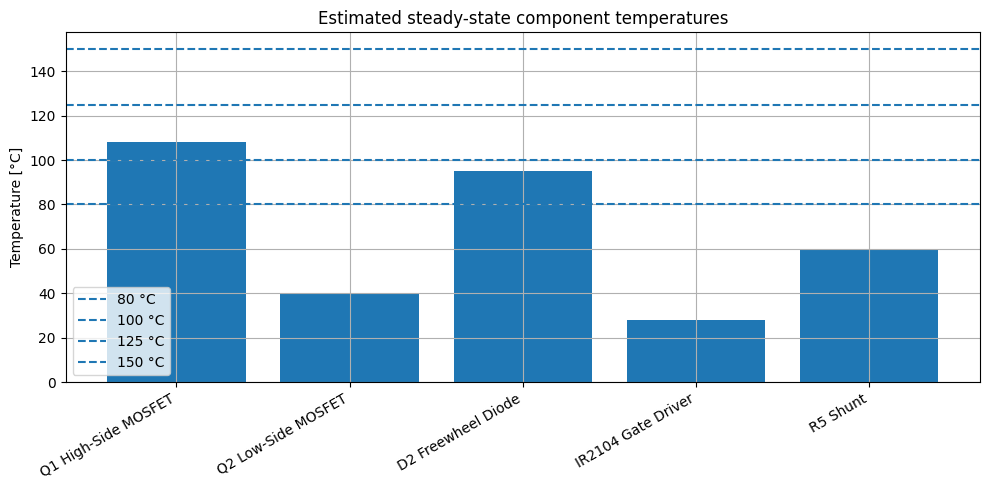

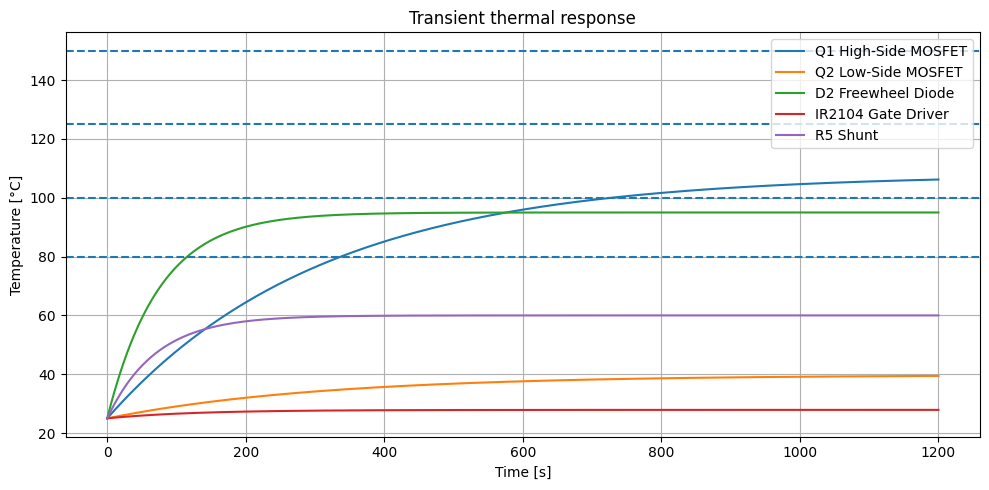

In [19]:
plot_temperature_bar(
    thermal_components,
    component_column="Component",
    temperature_column="T steady [°C]",
    title="Estimated steady-state component temperatures",
)

time_s = np.linspace(0.0, 1200.0, 1000)

temperature_results = {}

for _, row in thermal_components.iterrows():
    temperature_results[row["Component"]] = first_order_thermal_response(
        time_s=time_s,
        initial_temperature_c=T_ambient,
        ambient_temperature_c=T_ambient,
        power_loss_w=row["Power Loss [W]"],
        thermal_resistance_c_per_w=row["Rth [°C/W]"],
        thermal_capacitance_j_per_c=row["Cth [J/°C]"],
    )

plot_transient_temperatures(
    time_s,
    temperature_results,
    title="Transient thermal response",
)

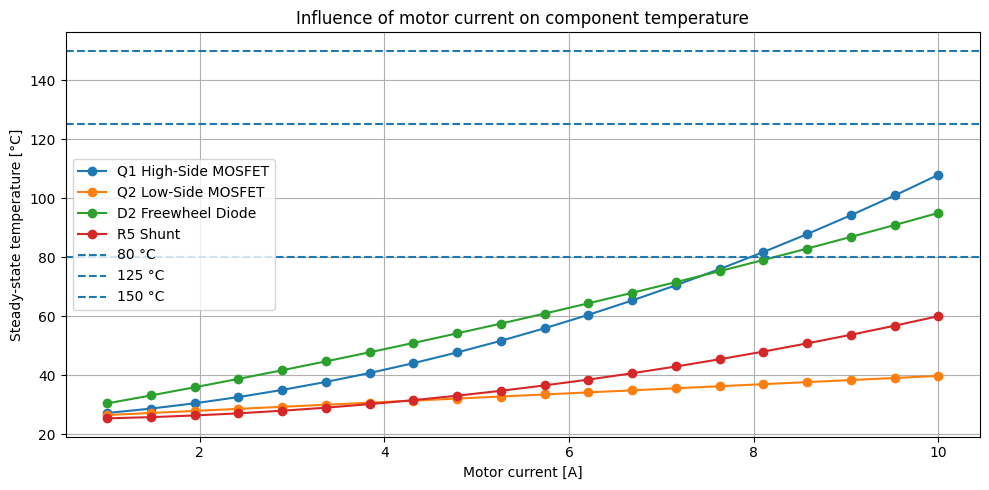

In [21]:
current_values = np.linspace(1.0, 10.0, 20)

q1_temperatures = []
q2_temperatures = []
diode_temperatures = []
shunt_temperatures = []

freewheel_mode = "diode"  # "diode" or "synchronous"

for current in current_values:
    p_q1_cond = mosfet_conduction_loss(
        current_a=current,
        duty=duty,
        rds_on_ohm=mosfet_high_side["Rds_on_used"],
    )

    p_q1_sw = mosfet_switching_loss(
        voltage_v=V_supply,
        current_a=current,
        rise_time_s=mosfet_high_side["tr"],
        fall_time_s=mosfet_high_side["tf"],
        pwm_frequency_hz=f_pwm,
    )

    p_q1_total = p_q1_cond + p_q1_sw

    if freewheel_mode == "synchronous":
        q2_duty = 1.0 - duty
    else:
        q2_duty = 0.0

    p_q2_cond = mosfet_conduction_loss(
        current_a=current,
        duty=q2_duty,
        rds_on_ohm=mosfet_low_side["Rds_on_used"],
    )

    p_q2_sw = mosfet_switching_loss(
        voltage_v=V_supply,
        current_a=current,
        rise_time_s=mosfet_low_side["tr"],
        fall_time_s=mosfet_low_side["tf"],
        pwm_frequency_hz=f_pwm,
    )

    p_q2_total = p_q2_cond + p_q2_sw

    if freewheel_mode == "diode":
        if_av = current * (1.0 - duty)
        if_rms = current * np.sqrt(1.0 - duty)

        p_diode = (
            freewheel_diode["loss_model_a"] * if_av
            + freewheel_diode["loss_model_b"] * if_rms**2
        )
    else:
        p_diode = 0.0

    p_shunt = shunt_loss(
        current_a=current,
        resistance_ohm=shunt["R"],
    )

    t_q1 = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_q1_total,
        thermal_resistance_c_per_w=mosfet_high_side["Rth_JA"],
    )

    t_q2 = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_q2_total,
        thermal_resistance_c_per_w=mosfet_low_side["Rth_JA"],
    )

    t_diode = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_diode,
        thermal_resistance_c_per_w=25.0,
    )

    t_shunt = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_shunt,
        thermal_resistance_c_per_w=shunt["Rth_JA"],
    )

    q1_temperatures.append(t_q1)
    q2_temperatures.append(t_q2)
    diode_temperatures.append(t_diode)
    shunt_temperatures.append(t_shunt)


plt.figure(figsize=(10, 5))
plt.plot(current_values, q1_temperatures, marker="o", label="Q1 High-Side MOSFET")
plt.plot(current_values, q2_temperatures, marker="o", label="Q2 Low-Side MOSFET")
plt.plot(current_values, diode_temperatures, marker="o", label="D2 Freewheel Diode")
plt.plot(current_values, shunt_temperatures, marker="o", label="R5 Shunt")

plt.axhline(80, linestyle="--", label="80 °C")
plt.axhline(125, linestyle="--", label="125 °C")
plt.axhline(150, linestyle="--", label="150 °C")

plt.xlabel("Motor current [A]")
plt.ylabel("Steady-state temperature [°C]")
plt.title("Influence of motor current on component temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

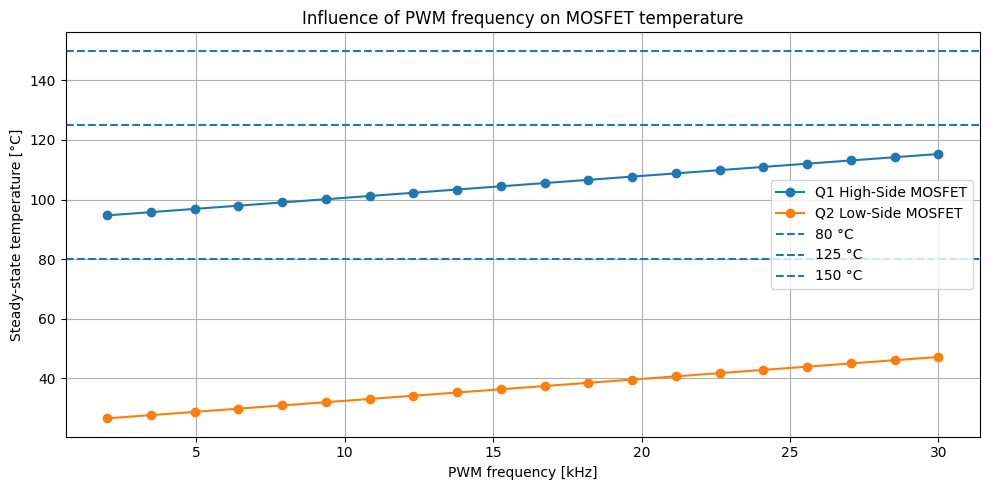

In [22]:
frequency_values = np.linspace(2e3, 30e3, 20)

q1_temperatures_frequency = []
q2_temperatures_frequency = []

freewheel_mode = "diode"  # "diode" or "synchronous"

for frequency in frequency_values:
    p_q1_cond = mosfet_conduction_loss(
        current_a=I_motor,
        duty=duty,
        rds_on_ohm=mosfet_high_side["Rds_on_used"],
    )

    p_q1_sw = mosfet_switching_loss(
        voltage_v=V_supply,
        current_a=I_motor,
        rise_time_s=mosfet_high_side["tr"],
        fall_time_s=mosfet_high_side["tf"],
        pwm_frequency_hz=frequency,
    )

    p_q1_total = p_q1_cond + p_q1_sw

    if freewheel_mode == "synchronous":
        q2_duty = 1.0 - duty
    else:
        q2_duty = 0.0

    p_q2_cond = mosfet_conduction_loss(
        current_a=I_motor,
        duty=q2_duty,
        rds_on_ohm=mosfet_low_side["Rds_on_used"],
    )

    p_q2_sw = mosfet_switching_loss(
        voltage_v=V_supply,
        current_a=I_motor,
        rise_time_s=mosfet_low_side["tr"],
        fall_time_s=mosfet_low_side["tf"],
        pwm_frequency_hz=frequency,
    )

    p_q2_total = p_q2_cond + p_q2_sw

    t_q1 = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_q1_total,
        thermal_resistance_c_per_w=mosfet_high_side["Rth_JA"],
    )

    t_q2 = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_q2_total,
        thermal_resistance_c_per_w=mosfet_low_side["Rth_JA"],
    )

    q1_temperatures_frequency.append(t_q1)
    q2_temperatures_frequency.append(t_q2)


plt.figure(figsize=(10, 5))
plt.plot(
    frequency_values / 1000.0,
    q1_temperatures_frequency,
    marker="o",
    label="Q1 High-Side MOSFET",
)
plt.plot(
    frequency_values / 1000.0,
    q2_temperatures_frequency,
    marker="o",
    label="Q2 Low-Side MOSFET",
)

plt.axhline(80, linestyle="--", label="80 °C")
plt.axhline(125, linestyle="--", label="125 °C")
plt.axhline(150, linestyle="--", label="150 °C")

plt.xlabel("PWM frequency [kHz]")
plt.ylabel("Steady-state temperature [°C]")
plt.title("Influence of PWM frequency on MOSFET temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

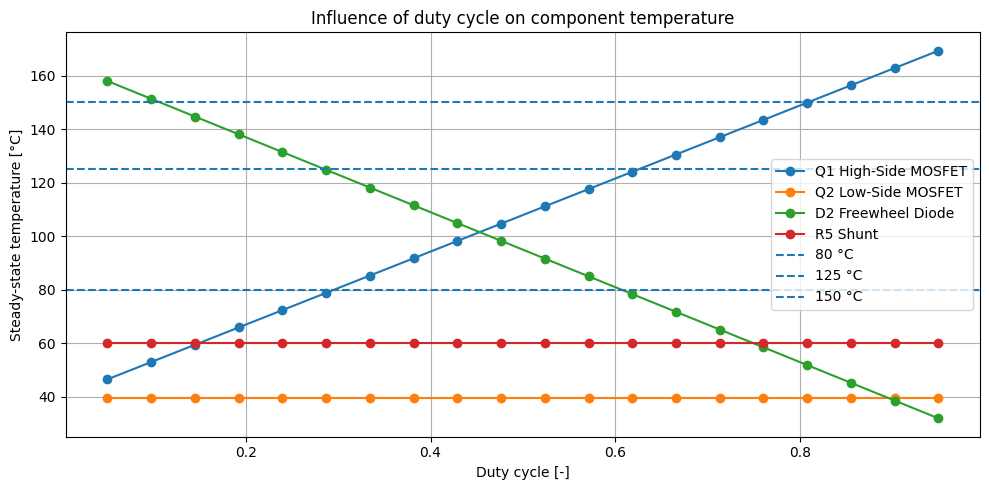

In [ ]:
duty_values = np.linspace(0.05, 0.95, 20)

q1_temperature_duty = []
q2_temperature_duty = []
diode_temperature_duty = []
shunt_temperature_duty = []

freewheel_mode = "diode"  # "diode" or "synchronous"

for d in duty_values:
    p_q1_cond = mosfet_conduction_loss(
        current_a=I_motor,
        duty=d,
        rds_on_ohm=mosfet_high_side["Rds_on_used"],
    )

    p_q1_sw = mosfet_switching_loss(
        voltage_v=V_supply,
        current_a=I_motor,
        rise_time_s=mosfet_high_side["tr"],
        fall_time_s=mosfet_high_side["tf"],
        pwm_frequency_hz=f_pwm,
    )

    p_q1_total = p_q1_cond + p_q1_sw

    if freewheel_mode == "synchronous":
        q2_duty = 1.0 - d
    else:
        q2_duty = 0.0

    p_q2_cond = mosfet_conduction_loss(
        current_a=I_motor,
        duty=q2_duty,
        rds_on_ohm=mosfet_low_side["Rds_on_used"],
    )

    p_q2_sw = mosfet_switching_loss(
        voltage_v=V_supply,
        current_a=I_motor,
        rise_time_s=mosfet_low_side["tr"],
        fall_time_s=mosfet_low_side["tf"],
        pwm_frequency_hz=f_pwm,
    )

    p_q2_total = p_q2_cond + p_q2_sw

    if freewheel_mode == "diode":
        if_av = I_motor * (1.0 - d)
        if_rms = I_motor * np.sqrt(1.0 - d)

        p_diode = (
            freewheel_diode["loss_model_a"] * if_av
            + freewheel_diode["loss_model_b"] * if_rms**2
        )
    else:
        p_diode = 0.0

    p_shunt = shunt_loss(
        current_a=I_motor,
        resistance_ohm=shunt["R"],
    )

    t_q1 = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_q1_total,
        thermal_resistance_c_per_w=mosfet_high_side["Rth_JA"],
    )

    t_q2 = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_q2_total,
        thermal_resistance_c_per_w=mosfet_low_side["Rth_JA"],
    )

    t_diode = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_diode,
        thermal_resistance_c_per_w=25.0,
    )

    t_shunt = steady_temperature(
        ambient_temperature_c=T_ambient,
        power_loss_w=p_shunt,
        thermal_resistance_c_per_w=shunt["Rth_JA"],
    )

    q1_temperature_duty.append(t_q1)
    q2_temperature_duty.append(t_q2)
    diode_temperature_duty.append(t_diode)
    shunt_temperature_duty.append(t_shunt)

q1_temperature_duty_wc = np.zeros_like(q1_temperature_duty)

for i in enumerate(q1_temperature_duty):
    
    q1_temperature_duty_wc[i] = q1_temperature_duty[i] - 


plt.figure(figsize=(10, 5))

plt.plot(
    duty_values,
    q1_temperature_duty,
    marker="o",
    label="Q1 High-Side MOSFET",
)

plt.plot(
    duty_values,
    q2_temperature_duty,
    marker="o",
    label="Q2 Low-Side MOSFET",
)

plt.plot(
    duty_values,
    diode_temperature_duty,
    marker="o",
    label="D2 Freewheel Diode",
)

plt.plot(
    duty_values,
    shunt_temperature_duty,
    marker="o",
    label="R5 Shunt",
)

plt.axhline(80, linestyle="--", label="80 °C")
plt.axhline(125, linestyle="--", label="125 °C")
plt.axhline(150, linestyle="--", label="150 °C")

plt.xlabel("Duty cycle [-]")
plt.ylabel("Steady-state temperature [°C]")
plt.title("Influence of duty cycle on component temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
def solve_mosfet_temperature_with_rds_feedback(
    ambient_temperature_c,
    current_a,
    duty,
    rds_on_ref,
    alpha_rds,
    voltage_v,
    rise_time_s,
    fall_time_s,
    pwm_frequency_hz,
    thermal_resistance_c_per_w,
    initial_guess_c=25.0,
    max_iterations=100,
    tolerance=1e-3,
):
    temperature = initial_guess_c

    for _ in range(max_iterations):
        rds = mosfet_rds_on_temperature(
            rds_on_25=rds_on_ref,
            temperature_c=temperature,
            alpha=alpha_rds,
        )

        p_cond = mosfet_conduction_loss(
            current_a=current_a,
            duty=duty,
            rds_on_ohm=rds,
        )

        p_sw = mosfet_switching_loss(
            voltage_v=voltage_v,
            current_a=current_a,
            rise_time_s=rise_time_s,
            fall_time_s=fall_time_s,
            pwm_frequency_hz=pwm_frequency_hz,
        )

        p_total = p_cond + p_sw

        new_temperature = steady_temperature(
            ambient_temperature_c=ambient_temperature_c,
            power_loss_w=p_total,
            thermal_resistance_c_per_w=thermal_resistance_c_per_w,
        )

        if abs(new_temperature - temperature) < tolerance:
            return new_temperature, p_total, rds

        temperature = new_temperature

    return temperature, p_total, rds


alpha_rds = 0.005  # rough temp. coefficient

T_q1_feedback, P_q1_feedback, Rds_q1_feedback = solve_mosfet_temperature_with_rds_feedback(
    ambient_temperature_c=T_ambient,
    current_a=I_motor,
    duty=duty,
    rds_on_ref=mosfet_high_side["Rds_on_used"],
    alpha_rds=alpha_rds,
    voltage_v=V_supply,
    rise_time_s=mosfet_high_side["tr"],
    fall_time_s=mosfet_high_side["tf"],
    pwm_frequency_hz=f_pwm,
    thermal_resistance_c_per_w=mosfet_high_side["Rth_JA"],
)

T_q1_without_feedback = thermal_components.loc[
    thermal_components["Component"] == "Q1 High-Side MOSFET",
    "T steady [°C]"
].iloc[0]

feedback_result = pd.DataFrame({
    "Quantity": [
        "Q1 temperature without Rds feedback",
        "Q1 temperature with Rds feedback",
        "Q1 power with Rds feedback",
        "Rds_on at final temperature",
    ],
    "Value": [
        T_q1_without_feedback,
        T_q1_feedback,
        P_q1_feedback,
        Rds_q1_feedback,
    ],
    "Unit": [
        "°C",
        "°C",
        "W",
        "Ohm",
    ],
})

feedback_result

,Quantity,Value,Unit
0,Q1 temperature without Rds feedback,107.931200,°C
1,Q1 temperature with Rds feedback,150.843695,°C
2,Q1 power with Rds feedback,2.029737,W
3,Rds_on at final temperature,0.035843,Ohm


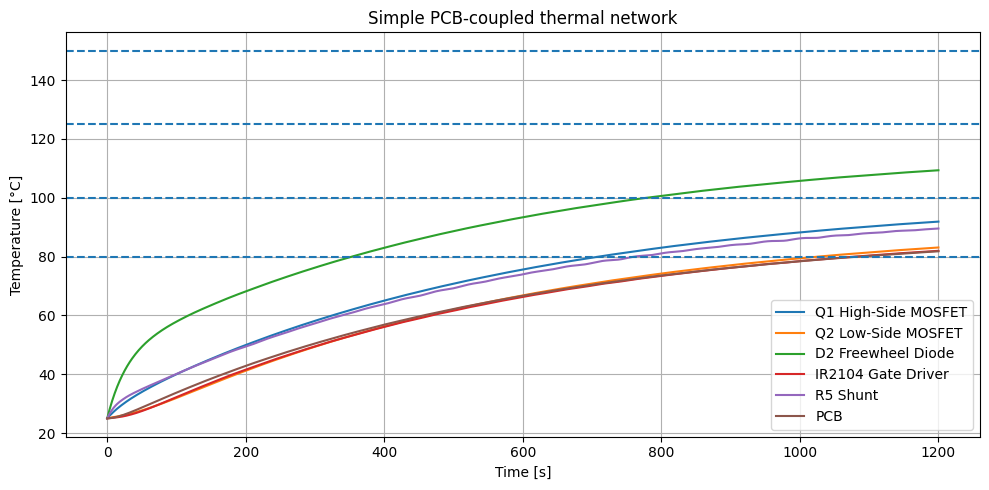

In [25]:
powers_w = {
    "Q1 High-Side MOSFET": P_q1_total,
    "Q2 Low-Side MOSFET": P_q2_total,
    "D2 Freewheel Diode": P_diode,
    "IR2104 Gate Driver": P_gate_total,
    "R5 Shunt": P_shunt,
}

component_to_pcb_resistances = {
    "Q1 High-Side MOSFET": 8.0,
    "Q2 Low-Side MOSFET": 8.0,
    "D2 Freewheel Diode": 10.0,
    "IR2104 Gate Driver": 20.0,
    "R5 Shunt": 8.0,
}

component_capacitances = {
    "Q1 High-Side MOSFET": mosfet_high_side["Cth"],
    "Q2 Low-Side MOSFET": mosfet_low_side["Cth"],
    "D2 Freewheel Diode": freewheel_diode["Cth"],
    "IR2104 Gate Driver": gate_driver["Cth"],
    "R5 Shunt": shunt["Cth"],
}

initial_temperatures = {
    "Q1 High-Side MOSFET": T_ambient,
    "Q2 Low-Side MOSFET": T_ambient,
    "D2 Freewheel Diode": T_ambient,
    "IR2104 Gate Driver": T_ambient,
    "R5 Shunt": T_ambient,
    "PCB": T_ambient,
}

time_network, network_results = simulate_pcb_coupled_network(
    time_span_s=(0.0, 1200.0),
    initial_temperatures_c=initial_temperatures,
    powers_w=powers_w,
    component_to_pcb_resistances_c_per_w=component_to_pcb_resistances,
    component_capacitances_j_per_c=component_capacitances,
    pcb_ambient_resistance_c_per_w=12.0,
    pcb_capacitance_j_per_c=30.0,
    ambient_temperature_c=T_ambient,
    number_of_points=1000,
)

plot_transient_temperatures(
    time_network,
    network_results,
    title="Simple PCB-coupled thermal network",
)